## Traitement des images

à faire : 
- cropper 30 pixels de chaque côté
- augmenter le niveau de noir du background
- centrer sur le sein
- couper en train / val / test

In [55]:
import sys
print(sys.executable)

c:\Users\Invite\AppData\Local\Programs\Python\Python313\python.exe


In [56]:
from PIL import Image
import os
import numpy as np
from skimage import filters, morphology, exposure, util, color
from skimage.filters import threshold_otsu, sobel
from skimage import filters, morphology, exposure
from skimage.restoration import denoise_bilateral
from skimage.segmentation import active_contour
from scipy.ndimage import binary_fill_holes, gaussian_filter1d
import cv2
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from tqdm import tqdm
from glob import glob
import random

In [57]:
# Utilitaire: crop des bords (30 px par défaut)
def crop_borders(img, pad=30):
    if img is None:
        return None
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            h, w = img.shape
            if h <= 2*pad or w <= 2*pad:
                return img.copy()
            return img[pad:h-pad, pad:w-pad]
        elif img.ndim == 3:
            h, w, _ = img.shape
            if h <= 2*pad or w <= 2*pad:
                return img.copy()
            return img[pad:h-pad, pad:w-pad, :]
    # Fallback pour objets type PIL
    try:
        arr = np.array(img)
    except Exception:
        return img
    return crop_borders(arr, pad)

In [58]:
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation, label as nd_label

# --- Helpers ---
def get_mask_of_largest_connected_component(mask: np.ndarray) -> np.ndarray:
    lab, n = nd_label(mask.astype(bool))
    if n == 0:
        return np.zeros_like(mask, dtype=bool)
    counts = np.bincount(lab.ravel())
    counts[0] = 0
    return lab == counts.argmax()

def get_edge_values(img: np.ndarray, mask: np.ndarray, axis: str):
    assert axis in ("x", "y")
    h, w = img.shape[:2]
    if axis == "y":
        rows = np.where(mask.any(axis=1))[0]
        y_top = int(rows.min()) if rows.size else 0
        y_bottom = int(rows.max()+1) if rows.size else h
        return y_top, y_bottom
    else:
        cols = np.where(mask.any(axis=0))[0]
        x_left = int(cols.min()) if cols.size else 0
        x_right = int(cols.max()+1) if cols.size else w
        return x_left, x_right

def get_bottommost_pixels(img: np.ndarray, mask: np.ndarray, y_edge_bottom: int):
    if y_edge_bottom <= 0:
        return 0, np.array([], dtype=int)
    y = int(y_edge_bottom - 1)
    xs = np.where(mask[y])[0]
    return y, xs

def include_buffer_y_axis(img: np.ndarray, y_top: int, y_bottom: int, buffer_size: int):
    h = img.shape[0]
    y_top = max(0, int(y_top - buffer_size))
    y_bottom = min(h, int(y_bottom + buffer_size))
    if y_top >= y_bottom:
        y_top, y_bottom = 0, h
    return y_top, y_bottom

def get_distance_from_starting_side(img: np.ndarray, mode: str, x_left: int, x_right: int):
    mask = (img > 0)
    col_sum = mask.sum(axis=0)
    nz = np.where(col_sum > 0)[0]
    if nz.size == 0:
        return 0
    if mode == "left":
        return int(nz[0])
    else:
        w = img.shape[1]
        return int((w - 1) - nz[-1])

def include_buffer_x_axis(img: np.ndarray, mode: str, x_left: int, x_right: int, buffer_size: int):
    w = img.shape[1]
    x_left = max(0, int(x_left - buffer_size))
    x_right = min(w, int(x_right + buffer_size))
    if x_left >= x_right:
        x_left, x_right = 0, w
    return x_left, x_right

def convert_bottommost_pixels_wrt_cropped_image(mode: str, bottom_y: int, bottom_xs: np.ndarray,
                                                 y_edge_top: int, x_edge_right: int, x_edge_left: int):
    h_c = None  # not needed here
    w_c = int(x_edge_right - x_edge_left)
    y_c = int(bottom_y - y_edge_top)
    xs_c = (bottom_xs - x_edge_left).astype(int)
    xs_c = xs_c[(xs_c >= 0) & (xs_c < w_c)]
    if mode == "right" and w_c > 0:
        xs_c = (w_c - 1) - xs_c
    return y_c, xs_c

def get_rightmost_pixels_wrt_cropped_image(mode: str, cropped_mask: np.ndarray, find_rightmost_from_ratio: float):
    h, w = cropped_mask.shape[:2]
    start_y = int(max(0, min(h - 1, np.floor(h * (1.0 - float(find_rightmost_from_ratio))))))
    m = cropped_mask if mode == "left" else np.fliplr(cropped_mask)
    ys = []
    xs_right = []
    for y in range(start_y, h):
        if m[y].any():
            ys.append(y)
            xs_right.append(np.max(np.where(m[y])[0]))
    if len(ys) == 0:
        return np.array([start_y]), 0
    y_start, y_end = int(min(ys)), int(max(ys))
    x_right = int(max(xs_right))
    return np.array([y_start, y_end]), x_right

# --- Required API ---
def crop_img_from_largest_connected(img, mode, erode_dialate=True, iterations=100,
                                    buffer_size=50, find_rightmost_from_ratio=1/3):
    """
    Performs erosion on the mask of the image, selects largest connected component,
    dilates it back, and computes a buffered crop and key points.

    Returns: (window_location, rightmost_points, bottommost_points, distance_from_starting_side)
    """
    assert mode in ("left", "right")
    assert img.ndim == 2, "img must be 2D grayscale"
    img_mask = img > 0
    if erode_dialate and iterations > 0:
        img_mask = binary_erosion(img_mask, iterations=iterations)
    largest_mask = get_mask_of_largest_connected_component(img_mask)
    if erode_dialate and iterations > 0:
        largest_mask = binary_dilation(largest_mask, iterations=iterations)

    y_edge_top, y_edge_bottom = get_edge_values(img, largest_mask, "y")
    x_edge_left, x_edge_right = get_edge_values(img, largest_mask, "x")

    bottommost_nonzero_y, bottommost_nonzero_x = get_bottommost_pixels(img, largest_mask, y_edge_bottom)
    y_edge_top, y_edge_bottom = include_buffer_y_axis(img, y_edge_top, y_edge_bottom, buffer_size)
    distance_from_starting_side = get_distance_from_starting_side(img, mode, x_edge_left, x_edge_right)
    x_edge_left, x_edge_right = include_buffer_x_axis(img, mode, x_edge_left, x_edge_right, buffer_size)

    # convert bottommost pixel locations w.r.t. cropped image. Flip if necessary.
    bottommost_nonzero_y, bottommost_nonzero_x = convert_bottommost_pixels_wrt_cropped_image(
        mode,
        bottommost_nonzero_y,
        bottommost_nonzero_x,
        y_edge_top,
        x_edge_right,
        x_edge_left
    )

    # rightmost from bottom portion (on cropped mask)
    cropped_mask = largest_mask[y_edge_top: y_edge_bottom, x_edge_left: x_edge_right]
    rightmost_nonzero_y, rightmost_nonzero_x = get_rightmost_pixels_wrt_cropped_image(
        mode, cropped_mask, find_rightmost_from_ratio
    )

    window_location = (y_edge_top, y_edge_bottom, x_edge_left, x_edge_right)
    rightmost_points = ((int(rightmost_nonzero_y[0]), int(rightmost_nonzero_y[-1])), int(rightmost_nonzero_x))
    bottommost_points = (int(bottommost_nonzero_y),
                         (int(bottommost_nonzero_x[0]) if bottommost_nonzero_x.size else 0,
                          int(bottommost_nonzero_x[-1]) if bottommost_nonzero_x.size else 0))
    return window_location, rightmost_points, bottommost_points, int(distance_from_starting_side)

def image_orientation(horizontal_flip, side):
    assert horizontal_flip in ['YES', 'NO'], "Wrong horizontal flip"
    assert side in ['L', 'R'], "Wrong side"
    if horizontal_flip == 'YES':
        return 'right' if side == 'R' else 'left'
    else:
        return 'left' if side == 'R' else 'right'

# --- Batch APIs (placeholders: require external project I/O utilities) ---
def crop_mammogram(input_data_folder, exam_list_path, cropped_exam_list_path, output_data_folder,
                   num_processes, num_iterations, buffer_size):
    raise NotImplementedError("This function depends on project-specific I/O (pickling, data_handling, Pool).")

def crop_mammogram_one_image(scan, input_file_path, output_file_path, num_iterations, buffer_size):
    raise NotImplementedError("This function depends on reading_images/saving_images utilities.")

def crop_mammogram_one_image_short_path(scan, input_data_folder, output_data_folder,
                                        num_iterations, buffer_size):
    raise NotImplementedError("This function depends on project-specific path layout.")

# Example usage with current image (commented):
# mode = image_orientation('NO', 'R')
# win_loc, rightmost_pts, bottommost_pts, dist = crop_img_from_largest_connected(img_uint8, mode,
#                                                                                 erode_dialate=True,
#                                                                                 iterations=20,
#                                                                                 buffer_size=50)
# print(win_loc, rightmost_pts, bottommost_pts, dist)

Niveaux de gris

In [59]:
# Transformation ponctuelle sur l'intensité
def transformation_intensite(img, T, max_int=255):
    table = np.array([T(i) for i in range(max_int+1)]).clip(0, max_int).astype(np.uint8)
    img_transformee = cv2.LUT(img, table)  # Applique la fonction à chaque pixel
    return img_transformee


In [60]:
def min_max_scale_grayscale(grayscale_image):
    # convert to numpy array
    img_array = np.array(grayscale_image).astype(np.float32)
    # min-max scaling
    min_val = img_array.min()
    max_val = img_array.max()
    if max_val - min_val == 0:
        # avoid division by zero : return black image or same image
        scaled_array = np.zeros_like(img_array, dtype=np.uint8)
    else:
        scaled_array = ((img_array - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    return scaled_array

In [61]:
def compute_mean_std(image_paths):
    n_pixels = 0
    channel_sum = 0.0
    channel_sum_squared = 0.0

    for img_path in tqdm(image_paths):
        #Read in grayscale
        img=cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        #Add a channel dimension for consistency (H, W, C)
        img = np.expand_dims(img, axis=-1)
        #Accumulate sums
        n_pixels += (img.shape[0] * img.shape[1])
        channel_sum += np.sum(img, axis=(0, 1))
        channel_sum_squared += np.sum(img**2, axis=(0, 1))

    #Compute mean and std
    mean = channel_sum / n_pixels
    std = np.sqrt((channel_sum_squared / n_pixels) - (mean ** 2))
    return mean, std

In [62]:
# Charger une image mammographique et normaliser via la moyenne/écart-type du dataset

image_path = r"C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Cancer\0001\C_0001_1.LEFT_CC.png"

# Déduire un dossier dataset à partir du chemin de l'image choisie (ex: le dossier "Cancer")
dataset_dir = os.path.dirname(os.path.dirname(image_path))

# Lister des images PNG du dataset (avec échantillonnage pour accélérer si nécessaire)
all_pngs = glob(os.path.join(dataset_dir, "**", "*.png"), recursive=True)
sample_n = min(500, len(all_pngs))  # ajuster au besoin
image_paths = random.sample(all_pngs, sample_n) if sample_n > 0 else [image_path]

# Statistiques globales du dataset
mean_u8, std_u8 = compute_mean_std(image_paths)
mean_u8 = float(np.atleast_1d(mean_u8)[0])
std_u8 = float(np.maximum(np.atleast_1d(std_u8)[0], 1e-6))
print(f"Dataset mean={mean_u8:.3f}, std={std_u8:.3f} (échelle 0-255), sur {len(image_paths)} images")

# Charger l'image cible (grayscale float32 0..255)
img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
img_gray = crop_borders(img_gray, pad=30)

# Normalisation basée dataset: z-score, puis remise à l'échelle [0,1] pour compatibilité avec le reste du pipeline
img_z = (img_gray - mean_u8) / std_u8
img01 = (img_z - img_z.min()) / max(img_z.max() - img_z.min(), 1e-6)

# Sorties attendues par les cellules suivantes
img_uint8 = (img01 * 255).astype(np.uint8)   # uint8 [0,255]
image = img01.astype(np.float32)              # float [0,1]

100%|██████████| 500/500 [00:30<00:00, 16.56it/s]



Dataset mean=32.391, std=50.709 (échelle 0-255), sur 500 images


CLAHE sauvegardé : C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Cancer\0001\C_0001_1.LEFT_CC_clahe.png


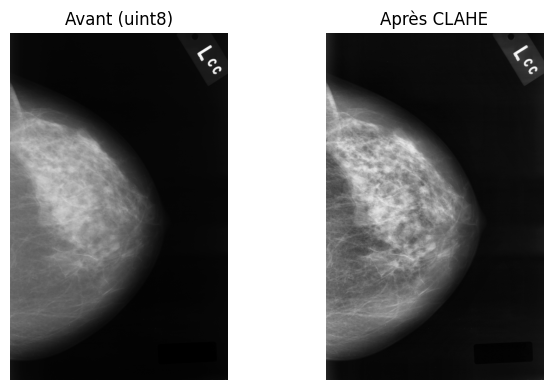

In [63]:
# Assurer uint8 mono-canal à partir de `image` ou réutiliser `img_uint8` existant
try:
    img_uint8
except NameError:
    if np.issubdtype(image.dtype, np.floating):
        img_uint8 = (np.clip(image, 0.0, 1.0) * 255).astype(np.uint8)
    elif image.dtype == np.uint16:
        lo, hi = np.percentile(image, (1, 99.5))
        img_uint8 = ((np.clip(image, lo, hi) - lo) / max(hi - lo, 1e-6) * 255).astype(np.uint8)
    else:
        img_uint8 = image.astype(np.uint8)

# Paramètres CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_uint8)

# Version float [0,1] si besoin pour la suite du pipeline
image_clahe = img_clahe.astype(np.float32) / 255.0

# Sauvegarde près de l'image source
base = os.path.splitext(os.path.basename(image_path))[0]
out_path = os.path.join(os.path.dirname(image_path), f"{base}_clahe.png")
cv2.imwrite(out_path, img_clahe)
print("CLAHE sauvegardé :", out_path)

# Affichage avant/après
fig, axes = plt.subplots(1, 2, figsize=(7, 4))
axes[0].imshow(img_uint8, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Avant (uint8)")
axes[0].axis('off')
axes[1].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Après CLAHE")
axes[1].axis('off')
plt.tight_layout(); plt.show()

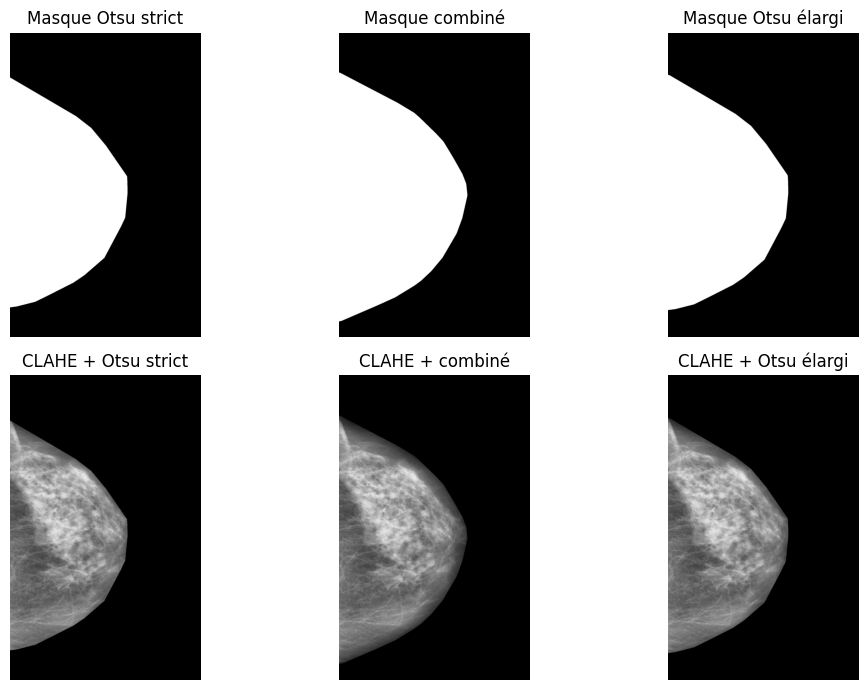

Pixels à 0 (CLAHE): 0.00% | Otsu strict: 67.48% | combiné: 62.27% | Otsu élargi: 65.83%
Otsu=0.2726 | thr_low=0.1636 | thr_scale=0.6


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
from skimage.measure import label
from scipy.ndimage import binary_fill_holes

# Paramètres
thr_scale = 0.6      # < 1.0 => seuil plus bas qu’Otsu (masque plus large)
min_size = 2000
closing_r = 7
dilation_r = 20
use_convex_hull = True

# Flou pour stabiliser le seuil
blur = gaussian(image, sigma=2.0, preserve_range=True)

# Otsu sur les pixels > 0
nz = blur[image > 0]
thr_otsu = threshold_otsu(nz) if nz.size else 0.02
thr_low = max(0.005, thr_otsu * thr_scale, np.percentile(nz, 1) if nz.size else 0.01)

def postprocess(mask, do_dilate=True):
    mask = morphology.remove_small_objects(mask, min_size=min_size)
    mask = binary_fill_holes(mask)
    mask = morphology.binary_closing(mask, morphology.disk(closing_r))
    lab = label(mask, connectivity=1)
    if lab.max() > 0:
        counts = np.bincount(lab.ravel()); counts[0] = 0
        mask = (lab == counts.argmax())
    if use_convex_hull:
        mask = morphology.convex_hull_image(mask)
    if do_dilate and dilation_r > 0:
        mask = morphology.binary_dilation(mask, morphology.disk(dilation_r))
    return mask

# 1) Variante stricte (masque d'Otsu exact, sans élargissement)
mask_strict = postprocess(blur > thr_otsu, do_dilate=False)

# 2) Variante combinée (au moins aussi large que l’un des deux)
mask_combined = postprocess((blur > thr_low) | (blur > thr_otsu), do_dilate=True)

# 3) Variante “Otsu élargi” (Otsu + dilatation)
mask_otsu_dil = postprocess(blur > thr_otsu, do_dilate=True)

def apply_mask(u8img, mask):
    out = u8img.copy()
    out[~mask] = 0
    return out

img_strict = apply_mask(img_clahe, mask_strict)
img_combined = apply_mask(img_clahe, mask_combined)
img_otsu_dil = apply_mask(img_clahe, mask_otsu_dil)

# Visualisation: lignes = [masques, images masquées], colonnes = [stricte, combinée, Otsu élargi]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes[0,0].imshow(mask_strict, cmap='gray');  axes[0,0].set_title("Masque Otsu strict");   axes[0,0].axis('off')
axes[0,1].imshow(mask_combined, cmap='gray');axes[0,1].set_title("Masque combiné");       axes[0,1].axis('off')
axes[0,2].imshow(mask_otsu_dil, cmap='gray');axes[0,2].set_title("Masque Otsu élargi");   axes[0,2].axis('off')

axes[1,0].imshow(img_strict, cmap='gray', vmin=0, vmax=255);  axes[1,0].set_title("CLAHE + Otsu strict");  axes[1,0].axis('off')
axes[1,1].imshow(img_combined, cmap='gray', vmin=0, vmax=255);axes[1,1].set_title("CLAHE + combiné");      axes[1,1].axis('off')
axes[1,2].imshow(img_otsu_dil, cmap='gray', vmin=0, vmax=255);axes[1,2].set_title("CLAHE + Otsu élargi");  axes[1,2].axis('off')
plt.tight_layout(); plt.show()

# Stats
pct0_old = 100.0 * (img_clahe == 0).mean()
pct0_strict = 100.0 * (img_strict == 0).mean()
pct0_combined = 100.0 * (img_combined == 0).mean()
pct0_otsu_dil = 100.0 * (img_otsu_dil == 0).mean()
print(f"Pixels à 0 (CLAHE): {pct0_old:.2f}% | Otsu strict: {pct0_strict:.2f}% | combiné: {pct0_combined:.2f}% | Otsu élargi: {pct0_otsu_dil:.2f}%")
print(f"Otsu={thr_otsu:.4f} | thr_low={thr_low:.4f} | thr_scale={thr_scale}")

In [65]:
def score_mask(mask, image_float01, blur_for_grad, border_px=10):
    h, w = mask.shape
    # 1) Taille du masque
    area_pct = 100.0 * mask.mean()

    # 2) Contact avec le bord (pour éviter d’englober le background)
    border = np.zeros_like(mask, dtype=bool)
    border[:border_px, :] = True; border[-border_px:, :] = True
    border[:, :border_px] = True; border[:, -border_px:] = True
    border_contact_pct = 100.0 * np.mean(mask & border)

    # 3) Fuite de fond: proportion de pixels très sombres à l’intérieur du masque
    leak_thresh = 0.02
    leak_pct = 100.0 * np.mean(image_float01[mask] < leak_thresh) if mask.any() else 100.0

    # 4) Alignement avec les bords (gradient sur la frontière du masque)
    grad = sobel(blur_for_grad)
    boundary = morphology.binary_dilation(mask, morphology.disk(1)) ^ mask
    edge_grad = float(grad[boundary].mean()) if boundary.any() else 0.0
    # normalisation par un percentile global pour comparaisons robustes
    g99 = np.percentile(grad, 99) if np.any(grad) else 1.0
    edge_grad_norm = edge_grad / max(g99, 1e-6)

    return {
        "area_pct": area_pct,
        "border_contact_pct": border_contact_pct,
        "leak_pct": leak_pct,
        "edge_grad_norm": edge_grad_norm
    }

def print_scores(name, s):
    print(f"{name:12s} | area={s['area_pct']:.1f}% | border={s['border_contact_pct']:.2f}% | "
          f"leak<{0.02}= {s['leak_pct']:.2f}% | edgeGradN={s['edge_grad_norm']:.3f}")

scores = {
    "Otsu strict":   score_mask(mask_strict, image, blur),
    "Combiné":       score_mask(mask_combined, image, blur),
    "Otsu élargi":   score_mask(mask_otsu_dil, image, blur),
}

for k in scores:
    print_scores(k, scores[k])

# Choix automatique simple: minimiser (leak, border), puis préférer un gradient de frontière élevé, puis zone modérée
def pick(scores_dict):
    items = []
    for name, s in scores_dict.items():
        # score composite (plus petit est mieux)
        composite = (
            1.0 * s["leak_pct"] +
            0.5 * s["border_contact_pct"] -
            5.0 * s["edge_grad_norm"] +
            0.1 * s["area_pct"]
        )
        items.append((composite, name))
    items.sort()
    return items[0][1]

recommended = pick(scores)
print(f"Recommandation: {recommended}")
# ...existing code...

Otsu strict  | area=32.5% | border=0.54% | leak<0.02= 0.00% | edgeGradN=0.307
Combiné      | area=37.7% | border=0.58% | leak<0.02= 0.00% | edgeGradN=0.171
Otsu élargi  | area=34.2% | border=0.55% | leak<0.02= 0.00% | edgeGradN=0.230
Recommandation: Otsu strict


On garde Otsu combiné (à discuter)

Mode estimé: right
Crop window: (256, 2175, 0, 994) | distance_from_starting_side: 460


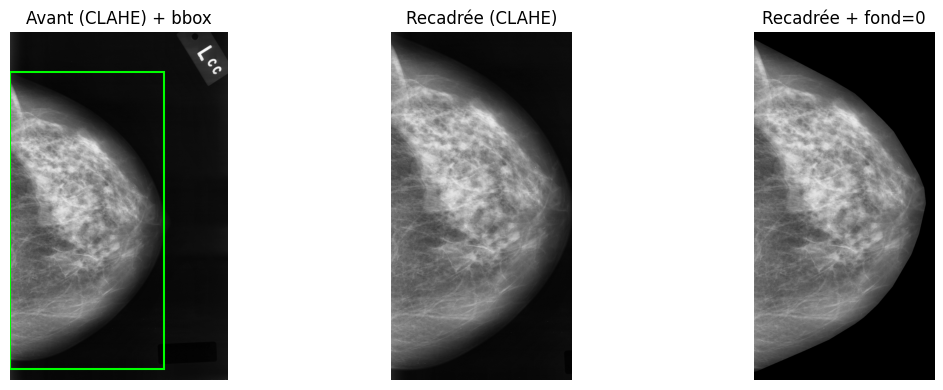

In [66]:
# Appliquer le crop basé sur la plus grande composante de l'image gardée (mask combiné)
def _guess_mode_from_mask(mask: np.ndarray) -> str:
    h, w = mask.shape[:2]
    cols = np.where(mask.any(axis=0))[0]
    if cols.size == 0:
        return 'left'
    left_gap = int(cols[0])
    right_gap = int((w - 1) - cols[-1])
    # Si le sein touche le bord gauche (gap gauche plus petit), le mamelon pointe vers la droite -> 'right'
    return 'right' if left_gap <= right_gap else 'left'

# Entrée = image gardée (img_combined = CLAHE masquée par mask_combined)
mode = _guess_mode_from_mask(mask_combined.astype(bool))
print('Mode estimé:', mode)

win_loc, rightmost_pts, bottommost_pts, dist_side = crop_img_from_largest_connected(
    img=img_combined,
    mode=mode,
    erode_dialate=True,
    iterations=20,
    buffer_size=50,
    find_rightmost_from_ratio=1/3
)
y_top, y_bot, x_left, x_right = win_loc
print('Crop window:', win_loc, '| distance_from_starting_side:', dist_side)

# Créer des sorties recadrées cohérentes pour la suite du pipeline
img_kept_cropped = img_clahe[y_top:y_bot, x_left:x_right]            # uint8 CLAHE recadrée
mask_kept_cropped = mask_combined[y_top:y_bot, x_left:x_right]        # masque recadré
image_kept_cropped = image[y_top:y_bot, x_left:x_right]               # float[0,1] recadrée

# Optionnel: remettre à zéro le fond en utilisant le masque recadré
img_kept_cropped_bg0 = img_kept_cropped.copy()
img_kept_cropped_bg0[~mask_kept_cropped] = 0

# Visualisation rapide
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
axes[0].add_patch(plt.Rectangle((x_left, y_top), x_right - x_left, y_bot - y_top,
                               fill=False, edgecolor='lime', linewidth=1.5))
axes[0].set_title('Avant (CLAHE) + bbox')
axes[0].axis('off')
axes[1].imshow(img_kept_cropped, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Recadrée (CLAHE)')
axes[1].axis('off')
axes[2].imshow(img_kept_cropped_bg0, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Recadrée + fond=0')
axes[2].axis('off')
plt.tight_layout(); plt.show()